In [ ]:
import pandas as pd
import numpy as np
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import *
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullFitter



 # 批量生成9组数据
sample_sizes = [50, 100, 200]
censor_rates  = [0.1, 0.3, 0.5]

sim_data_dict = {}
for n in sample_sizes:
    for cp in censor_rates:
        sim_data_dict[(n, cp)] = gen_surv(
            n=n,
            shape=1.2,
            scale=365,
            age_mean=65,
            age_std=10,
            gender_p=0.5,
            target_censor=cp
        )


In [2]:
np.random.seed(42)
# 遍历9组数据输出描述统计
desc_stats = []
for (n, cp), data in sim_data_dict.items():
    df = data.copy()
    obs_time = df['survival_time'].mean()
    obs_events = df['event'].mean()
    age_mean = df['age'].mean()
    gender_ratio = df['gender'].mean()
    
    desc_stats.append({
        '样本量': n,
        '目标删失率': cp,
        '实际删失率': round(1 - obs_events, 3),
        '生存时间均值': round(obs_time, 1),
        '年龄均值': round(age_mean, 1),
        '性别比例(男=1)': round(gender_ratio, 3)
    })

desc_df = pd.DataFrame(desc_stats)
desc_df

,样本量,目标删失率,实际删失率,生存时间均值,年龄均值,性别比例(男=1)
0,50,0.1,0.100,323.9,66.5,0.560
1,50,0.3,0.300,357.9,62.6,0.540
2,50,0.5,0.480,295.4,65.3,0.520
3,100,0.1,0.100,335.6,65.2,0.480
4,100,0.3,0.300,329.2,65.9,0.510
5,100,0.5,0.500,199.4,65.3,0.470
6,200,0.1,0.100,340.8,64.0,0.500
7,200,0.3,0.295,274.5,65.2,0.485
8,200,0.5,0.500,242.6,63.9,0.480


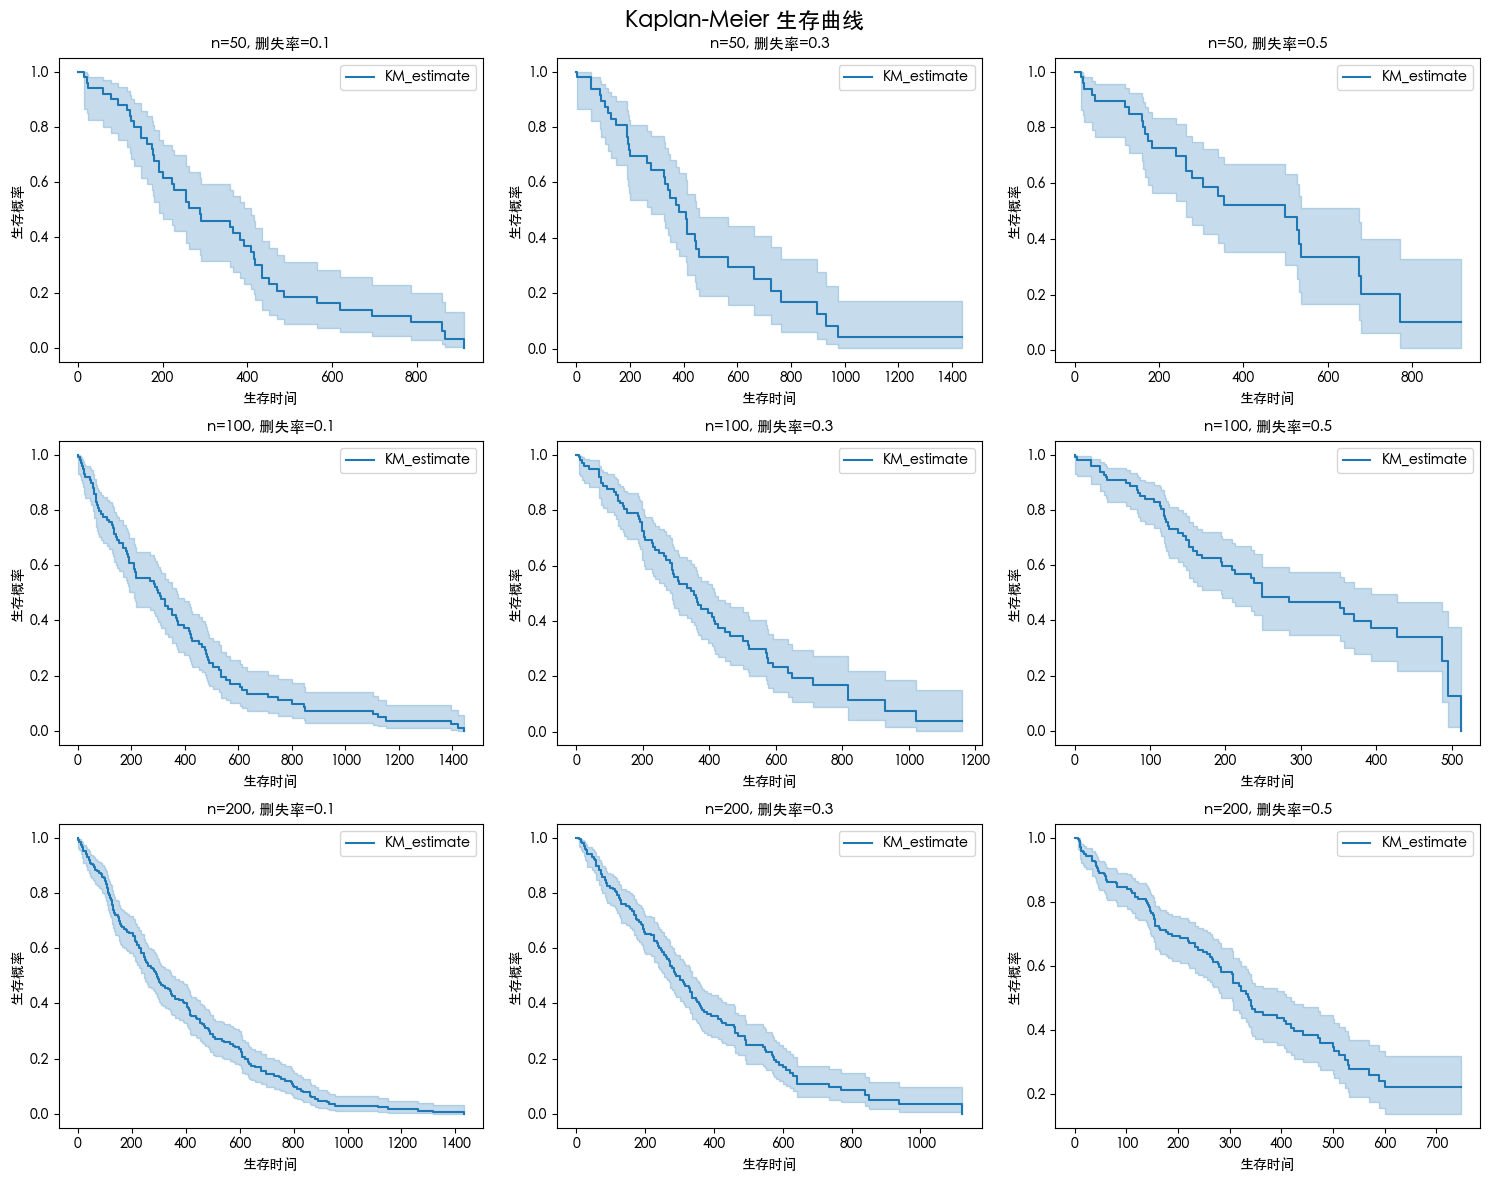

=== 样本量50_删失率0.1 模型拟合结果 ===

【Cox模型摘要】


<lifelines.CoxPHFitter: fitted with 50 total observations, 5 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 50
number of events observed = 45
   partial log-likelihood = -132.833
         time fit was run = 2026-03-28 12:27:52 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age        0.016     1.017     0.015          -0.013           0.046               0.987               1.047
gender    -0.120     0.887     0.311          -0.729           0.489               0.482               1.631

           cmp to      z     p  -log2(p)
covariate                               
age         0.000  1.093 0.274     1.866
gender      0.000 -0.387 0.699     0.517
---
Concordance = 0.574
Partial AIC = 269.665
log-likelihood ratio test = 1.523 on 2 df
-log2(p) of ll-ratio test = 1.099


【威布尔模型参数】
形状参数λ: 382.154
尺度参数ρ: 1.388
=== 样本量50_删失率0.3 模型拟合结果 ===

【Cox模型摘要】


<lifelines.CoxPHFitter: fitted with 50 total observations, 15 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 50
number of events observed = 35
   partial log-likelihood = -102.140
         time fit was run = 2026-03-28 12:27:52 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age        0.025     1.025     0.021          -0.016           0.066               0.984               1.069
gender    -0.638     0.528     0.352          -1.327           0.051               0.265               1.053

           cmp to      z     p  -log2(p)
covariate                               
age         0.000  1.196 0.232     2.109
gender      0.000 -1.814 0.070     3.842
---
Concordance = 0.631
Partial AIC = 208.280
log-likelihood ratio test = 3.853 on 2 df
-log2(p) of ll-ratio test = 2.779


【威布尔模型参数】
形状参数λ: 510.613
尺度参数ρ: 1.274
=== 样本量50_删失率0.5 模型拟合结果 ===

【Cox模型摘要】


...


【威布尔模型参数】
形状参数λ: 395.308
尺度参数ρ: 1.188
=== 样本量200_删失率0.3 模型拟合结果 ===

【Cox模型摘要】


<lifelines.CoxPHFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 141
   partial log-likelihood = -602.656
         time fit was run = 2026-03-28 12:27:52 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age        0.020     1.020     0.009           0.003           0.038               1.003               1.039
gender    -0.246     0.782     0.171          -0.580           0.089               0.560               1.093

           cmp to      z     p  -log2(p)
covariate                               
age         0.000  2.242 0.025     5.326
gender      0.000 -1.438 0.150     2.734
---
Concordance = 0.568
Partial AIC = 1209.313
log-likelihood ratio test = 7.458 on 2 df
-log2(p) of ll-ratio test = 5.380


【威布尔模型参数】
形状参数λ: 389.904
尺度参数ρ: 1.276
=== 样本量200_删失率0.5 模型拟合结果 ===

【Cox模型摘要】


<lifelines.CoxPHFitter: fitted with 200 total observations, 100 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 100
   partial log-likelihood = -447.829
         time fit was run = 2026-03-28 12:27:52 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age       -0.002     0.998     0.010          -0.023           0.018               0.978               1.018
gender    -0.209     0.811     0.204          -0.610           0.191               0.544               1.210

           cmp to      z     p  -log2(p)
covariate                               
age         0.000 -0.227 0.820     0.286
gender      0.000 -1.026 0.305     1.713
---
Concordance = 0.540
Partial AIC = 899.658
log-likelihood ratio test = 1.198 on 2 df
-log2(p) of ll-ratio test = 0.864


【威布尔模型参数】
形状参数λ: 473.221
尺度参数ρ: 1.076


In [ ]:

# 防止乱码
plt.rcParams["font.family"] = [  "Heiti TC"] 
plt.rcParams["axes.unicode_minus"] = False 

# 三大生存模型拟合
model_results = {}  

for (n, cp), data in sim_data_dict.items():
    df = data.copy()
    key = f"样本量{n}_删失率{cp}"
    # 1. Kaplan-Meier 
    kmf = KaplanMeierFitter()
    kmf.fit(data["survival_time"], event_observed=data["event"])
    km_model = kmf
    # 2. Cox 
    cph = CoxPHFitter()
    cph.fit(df, duration_col="survival_time", event_col="event")
    cox_model = cph
    # 3. 威布尔
    wbf = WeibullFitter()
    wbf.fit(df["survival_time"] + 1e-6, df["event"])
    weibull_model = wbf

    model_results[key] = {
        "km": km_model,
        "cox": cox_model,
        "weibull": weibull_model
    }
# 绘图
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12)) 
axes = axes.flatten()  
for idx, ((n, cp), data) in enumerate(sim_data_dict.items()):
    ax = axes[idx]  
    
    # 拟合 Kaplan-Meier 模型
    kmf = model_results[f"样本量{n}_删失率{cp}"]["km"]    # 绘制生存曲线
    kmf.plot_survival_function(ax=ax)
    ax.set_title(f"n={n}, 删失率={cp}", fontsize=11)
    ax.set_xlabel("生存时间", fontsize=10)
    ax.set_ylabel("生存概率", fontsize=10)

fig.suptitle("Kaplan-Meier 生存曲线", fontsize=16, y=0.98)  # 总标题
plt.tight_layout()
plt.show()

# 输出模型摘要（验证拟合成功）
for i in range(9):
    test_key = list(model_results.keys())[i]
    print(f"=== {test_key} 模型拟合结果 ===")
    print("\n【Cox模型摘要】")
    model_results[test_key]["cox"].print_summary(decimals=3)
    print("\n【威布尔模型参数】")
    print(f"形状参数λ: {model_results[test_key]['weibull'].lambda_:.3f}")
    print(f"尺度参数ρ: {model_results[test_key]['weibull'].rho_:.3f}")